# Instagram Social Media Analysis

In [ ]:
# Set-up
%load_ext sql
%sql sqlite://
import pandas as pd

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [ ]:
from google.colab import files

# Upload all 7 files (you can select them together in the file picker)
uploaded = files.upload()

Saving follows.csv to follows.csv
Saving likes.csv to likes.csv
Saving photos.csv to photos.csv
Saving comments.csv to comments.csv
Saving users.csv to users.csv
Saving photos_tags.csv to photos_tags.csv
Saving tags.csv to tags.csv


In [ ]:
import pandas as pd

users = pd.read_csv('users.csv', encoding='unicode_escape')
comments = pd.read_csv('comments.csv', encoding='unicode_escape')
likes = pd.read_csv('likes.csv', encoding='unicode_escape')
follows = pd.read_csv('follows.csv', encoding='unicode_escape')
photos = pd.read_csv('photos.csv', encoding='unicode_escape')
photos_tags = pd.read_csv('photos_tags.csv', encoding='unicode_escape')
tags = pd.read_csv('tags.csv', encoding='unicode_escape')


In [ ]:
%load_ext sql


The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [ ]:
%sql DROP TABLE IF EXISTS users
%sql DROP TABLE IF EXISTS comments
%sql DROP TABLE IF EXISTS likes
%sql DROP TABLE IF EXISTS follows
%sql DROP TABLE IF EXISTS photos
%sql DROP TABLE IF EXISTS photos_tags
%sql DROP TABLE IF EXISTS tags

%sql --persist users
%sql --persist comments
%sql --persist likes
%sql --persist follows
%sql --persist photos
%sql --persist photos_tags
%sql --persist tags


 * sqlite://
Done.
 * sqlite://
Done.
 * sqlite://
Done.
 * sqlite://
Done.
 * sqlite://
Done.
 * sqlite://
Done.
 * sqlite://
Done.
 * sqlite://
 * sqlite://
 * sqlite://
 * sqlite://
 * sqlite://
 * sqlite://
 * sqlite://


'Persisted tags'

## Instagram User Social Media Analysis

Instagram has become one of the most influential social media platforms, shaping trends, consumer behavior, and digital marketing strategies. Analyzing Instagram data—such as user interactions, post engagements, and follower networks provides valuable insights into content performance, audience preferences, and platform dynamics.

In this project, I leveraged SQL to explore key metrics from Instagram datasets, including user activity, likes, comments, and hashtag usage. By querying relational tables containing structured data, I uncovered patterns in engagement, identify popular content types, and assessed network growth.

This analysis demonstrates how database techniques can extract meaningful business intelligence from social media interactions, helping creators and marketers optimize their strategies for greater reach and impact.

**Project Overview**

The goal was to derive insights from various datasets reflecting typical social media behaviors and interactions.

The datasets include:

users.csv: User information and signup data

photos.csv: Shared images by users

likes.csv: Likes on photos

comments.csv: Comments made by users

follows.csv: Follow relationships between users

photo_tags.csv: Tags assigned to photos

tags.csv: The actual tag names used

**Objectives of the Analysis**

The analysis aimed to provide answers to strategic questions like:

Which users are active or inactive over a period of time?

How can we identify and reward long-term or loyal users?

Who are the users with the most likes and the most follows?

What are the most used or trending hashtags?

Are user engagement levels growing over time?

Can we recommend ideal windows for ad campaigns?

How can we build a schedule for email targeting inactive users?

Create Tables using SQL

In [ ]:
%%sql
CREATE TABLE users (
    username VARCHAR(255) NOT NULL,
    created_at TIMESTAMP NOT NULL,
     id SERIAL PRIMARY KEY);

 * sqlite://
Done.


[]

In [ ]:
%%sql
CREATE TABLE users (
    username VARCHAR(255) NOT NULL,
    created_at TIMESTAMP NOT NULL,
     id SERIAL PRIMARY KEY);

 * sqlite://
Done.


[]

In [ ]:
%%sql
-- PHOTOS table
CREATE TABLE photos (
    image_url VARCHAR(255) NOT NULL,
    user_id INT NOT NULL,
    id SERIAL PRIMARY KEY,
    created_at TIMESTAMP NOT NULL);

-- COMMENTS table
CREATE TABLE comments (
    comment_text VARCHAR(255) NOT NULL,
    user_id INT,
    photo_id INT,
    id SERIAL PRIMARY KEY,
    created_at TIMESTAMP NOT NULL);

-- LIKES table
CREATE TABLE likes (
    user_id INT,
    photo_id INT,
    created_at TIMESTAMP NOT NULL);

-- FOLLOWS table
CREATE TABLE follows (
    follower_id INT,
    followee_id INT,
    created_at TIMESTAMP NOT NULL);

-- TAGS table
CREATE TABLE tags (
    tag_name VARCHAR(100),
    id SERIAL PRIMARY KEY,
    created_at TIMESTAMP NOT NULL);

-- PHOTOS-TAGS Junction table
CREATE TABLE photos_tags (
    photo_id INT ,
    tag_id INT);

The original csv file for some tables didn't carry the "created_at" column so I created a temporary table for import that matches the file’s columns. Afterwards, i imported them into the actual tables Using JOIN to Get "created_at" from 'users' table

In [ ]:
%%sql
-- 1. TEMP COMMENTS TABLE
CREATE TABLE temp_comments (
    comment_text TEXT,
    user_id INT,
    photo_id INT);

-- Insert into comments using created_at from users table
INSERT INTO comments (comment_text, user_id, photo_id, created_at)
SELECT
    tc.comment_text,
    tc.user_id,
    tc.photo_id,
    u.created_at
FROM temp_comments AS tc
JOIN users AS u ON tc.user_id = u.id;

-----------------------------------------------------------

-- 2. TEMP PHOTOS TABLE
CREATE TABLE temp_photos (
    image_url VARCHAR(255) NOT NULL,
    user_id INT NOT NULL);

-- Insert into photos using created_at from users table
INSERT INTO photos (image_url, user_id, created_at)
SELECT
    tp.image_url,
    tp.user_id,
    u.created_at
FROM temp_photos AS tp
JOIN users AS u ON tp.user_id = u.id;

-----------------------------------------------------------

-- 3. TEMP LIKES TABLE
CREATE TABLE temp_likes (
    user_id INT,
    photo_id INT);

-- Insert into likes using created_at from users table
INSERT INTO likes (user_id, photo_id, created_at)
SELECT
    tl.user_id,
    tl.photo_id,
    u.created_at
FROM temp_likes AS tl
JOIN users AS u ON tl.user_id = u.id;

-----------------------------------------------------------

-- 4. TEMP PHOTO_TAGS TABLE
CREATE TABLE temp_photo_tags (
    photo_id INT,
    tag_id INT);

-- Insert into photo_tags using created_at from photos table
INSERT INTO photo_tags (photo_id, tag_id, created_at)
SELECT
    tpt.photo_id,
    tpt.tag_id,
    p.created_at
FROM temp_photo_tags AS tpt
JOIN photos AS p ON tpt.photo_id = p.id;

-----------------------------------------------------------

-- 5. TAGS TABLE
CREATE TABLE tags (
    id SERIAL PRIMARY KEY,
    tag_name VARCHAR(255) NOT NULL,
    created_at TIMESTAMP);

-- If you're generating tag names manually:
-- Use this temp_tags table to map tag_name to a created_at
CREATE TABLE temp_tags (
    tag_name VARCHAR(255) NOT NULL,
    created_at TIMESTAMP);

-- Insert into main tags table
INSERT INTO tags (tag_name, created_at)
SELECT
    tt.tag_name,
    tt.created_at
FROM temp_tags AS tt;

-----------------------------------------------------------

-- 6. TEMP FOLLOWS TABLE
CREATE TABLE temp_follows (
    follower_id INT,
    followee_id INT);

-- Insert into follows using followee’s created_at as follow time
INSERT INTO follows (follower_id, followee_id, created_at)
SELECT
    tf.follower_id,
    tf.followee_id,
    u.created_at
FROM temp_follows AS tf
JOIN users AS u ON tf.followee_id = u.id;


**Rewarding the Oldest Customers**

Users who joined earliest and are still active (e.g. still liking/commenting/photos).

In [ ]:
%%sql
SELECT users.username, users.id, COUNT(photos.id) AS photos_posted, users.created_at
FROM users
JOIN photos ON users.id = photos.user_id
GROUP BY users.id
ORDER BY users.created_at
LIMIT 10;

![alt text] 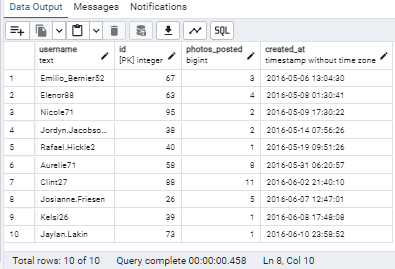

**Ad Campaign Schedule**

Days/times when most users are active (likes/comments/uploads).

In [ ]:
%%sql
--TO GET THE HOUR WHEN MOST USERS ARE ACTIVE
SELECT EXTRACT (HOUR from created_at) as hour, COUNT(*) AS activity
FROM (
    SELECT created_at FROM Likes
    UNION ALL
    SELECT created_at FROM Comments
    UNION ALL
    SELECT created_at FROM Photos) AS pr
GROUP BY hour
ORDER BY activity DESC;

--TO GET THE DAY MOST USERS ARE ACTIVE
SELECT EXTRACT (HOUR from created_at) as hour_of_day, day_of_week,
       COUNT(*) AS activity
FROM (
    SELECT created_at, day_of_week FROM Likes
    UNION ALL
    SELECT created_at, day_of_week FROM Comments
    UNION ALL
    SELECT created_at, day_of_week FROM Photos) AS pr
GROUP BY hour_of_day, day_of_week
ORDER BY activity DESC;



![alt text]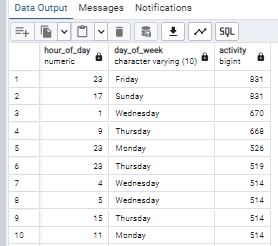

Best Posting time is Fridays at 11pm, since it's the weekend lots of persons are online.

**Email Inactive Users**

Users who haven't posted, liked, or commented in the last 30 days.This is so we can target them with a reactivation email campaign.

In [ ]:
%%sql
--TO GET THE MAXIMUM DATE IN THIS DATA AS A REFERENCE FOR CURRENT DATE
SELECT MAX(created_at) FROM (
    SELECT created_at FROM photos
    UNION ALL
    SELECT created_at FROM comments
    UNION ALL
    SELECT created_at FROM likes
    UNION ALL
    SELECT created_at FROM follows
) AS all_activity;


![alt text]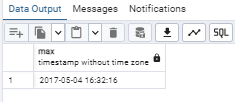

We use 30 days as a standard, flexible time window to identify inactive users. The query below gives us a list of active users. In other words, Show me users who were active in the last 30 days before the most recent date in the data.

In [ ]:
%%sql
SELECT DISTINCT user_id
FROM (
    SELECT user_id, created_at FROM photos WHERE created_at > DATE '2017-05-04' - INTERVAL '30 days'
    UNION
    SELECT user_id, created_at FROM comments WHERE created_at > DATE '2017-05-04' - INTERVAL '30 days'
    UNION
    SELECT user_id, created_at FROM likes WHERE created_at > DATE '2017-05-04' - INTERVAL '30 days'
    UNION
    SELECT follower_id AS user_id, created_at FROM follows WHERE created_at > DATE '2017-05-04' - INTERVAL '30 days'
) recent_activity;


![alt text]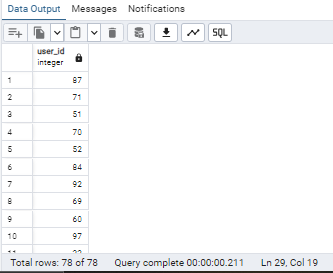

We use 30 days as a standard, flexible time window to identify inactive users. The query below gives us a list of users who have not done anything in 30 days.In other words, Give me all users who are not in the list of users who did anything in the last 30 days (from the most recent date in my data).

In [ ]:
%%sql
SELECT id, username, created_at
FROM users
WHERE id NOT IN (
    SELECT DISTINCT user_id
    FROM (
        SELECT user_id FROM photos WHERE created_at > DATE '2017-05-04' - INTERVAL '30 days'
        UNION
        SELECT user_id FROM comments WHERE created_at > DATE '2017-05-04' - INTERVAL '30 days'
        UNION
        SELECT user_id FROM likes WHERE created_at > DATE '2017-05-04' - INTERVAL '30 days'
        UNION
        SELECT follower_id AS user_id FROM follows WHERE created_at > DATE '2017-05-04' - INTERVAL '30 days'
    ) AS recent_activity
);


![alt text]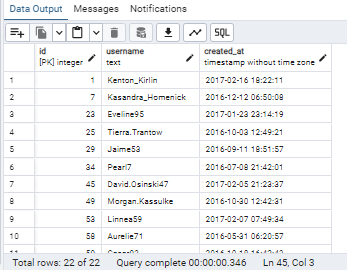

**Photo Contest**

We have decided to run a new contest to see who can get the most likes on a single photo on Instagram till now. We will be distributing gifts to the top 10 users with most likes on a singe photo of theirs.

In [ ]:
%%sql
SELECT p.user_id, u.username, p.id AS photo_id, COUNT(l.user_id) AS likes_count
FROM photos AS p
JOIN likes AS l ON p.id = l.photo_id
JOIN users AS u ON u.id = p.user_id
GROUP BY p.user_id, u.username, p.id
ORDER BY likes_count DESC
LIMIT 10;

![alt text]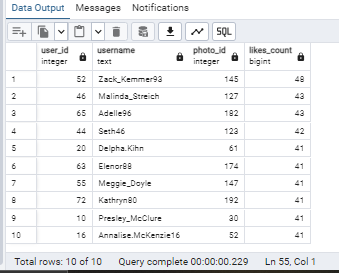

**User Activity Analysis**

The investors of Instagram wants to know The total post made by a user and how many times does the average user posts a photo.

In [ ]:
%%sql
SELECT
  u.id AS user_id,
  u.username,
  COUNT(p.id) AS total_photos
FROM users AS u
JOIN photos AS p ON u.id = p.user_id
GROUP BY u.id, u.username
ORDER BY total_photos DESC;


![alt text] 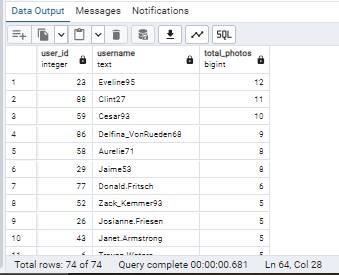

In [ ]:
%%sql
SELECT ROUND(AVG(photo_count),2) AS average_posts
FROM(
SELECT user_id, COUNT(p.id) AS photo_count
FROM photos AS p
GROUP BY user_id
) AS user_photo_counts;


![alt text] 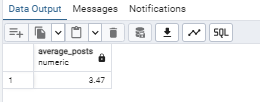

Average number of posts by a user is about 3.

**Meeting Posts Target**

The investors have set a target for the total number of posts per month at 30 for the continuation of their investment. Hence, we should keep a check if we are able to meet the target

In [ ]:
%%sql
SELECT EXTRACT(YEAR FROM created_at) AS year,
       TO_CHAR (created_at, 'Month') AS month,
COUNT(*) AS photos_posted
FROM photos
GROUP BY year,month
ORDER BY photos_posted DESC;


![alt text] 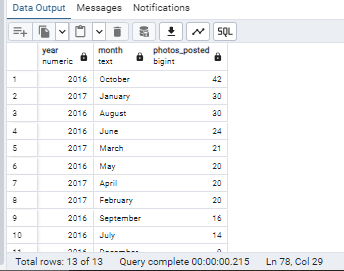

To get not just the months but the year where targets where met.



In [ ]:
%%sql
SELECT EXTRACT(YEAR FROM created_at) AS year,
       TO_CHAR (created_at, 'Month') AS month,
	   30 as monthly_target, COUNT(*) AS photos_posted,
CASE
    WHEN COUNT(*) >= 30 THEN 'Target Met' ELSE 'Below Target' END AS performance
FROM photos
GROUP BY year,month
ORDER BY photos_posted DESC;


![alt text]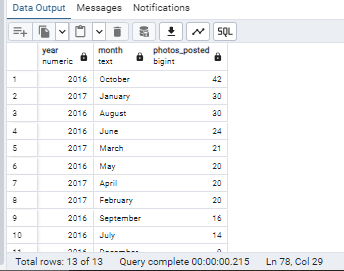

we can see that posts in October 2016 exceeded the target set by our investors by a healthy margin of 42 posts.

**Idle Users**

In order to focus marketing efforts on a particular idle segment of customers, it is necessary to know how many of our users have posted at least 1 photo on their Instagram social media accounts.

In [ ]:
%%sql
SELECT COUNT(DISTINCT user_id) AS users_with_posts
FROM photos;

![alt text]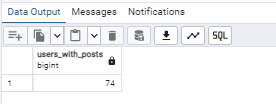

As we can see, 74 of our users have posted at least 1 photo while rest 26 did not post any. Hence, we know the proportion of our idle customers who would be targeted during marketing.

**Popular Hashtags**

A brand wishes to target a segment of or audience in their next marketing and product design campaign. For that, they wish to know which are the most popular hashtags our users use so that they can invest in something popular and trendy. Hence, we should find the most used hashtags on Instagram.

In [ ]:
%%sql
SELECT tags.tag_name, COUNT(*) AS usage_count
FROM tags
JOIN photos_tags ON photos_tags.tag_id = tags.id
GROUP BY tag_name
ORDER BY usage_count DESC;


![alt text]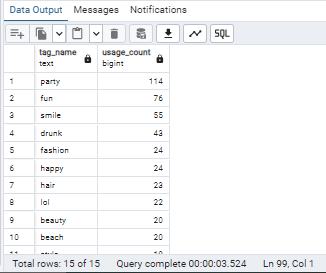

**Users with highest number of likes and follows**

Users with highest number of followers and likes on their posts.


In [ ]:
%%sql
---USERS WITH THE HIGHEST LIKES
SELECT l.user_id, u.username, COUNT (*) AS total_likes
FROM likes AS l
JOIN users AS u ON l.user_id = u.id
GROUP BY l.user_id, u.username
HAVING COUNT (*) = (
                       SELECT COUNT(*)
                       FROM photos);

---USERS WITH THE MOST FOLLOWERS
SELECT u.id,u.username, COUNT(*)  AS total_follows
FROM follows AS f
JOIN users AS u ON f.followee_id = u.id
GROUP BY u.username, u.id
ORDER BY total_follows DESC;

![alt text]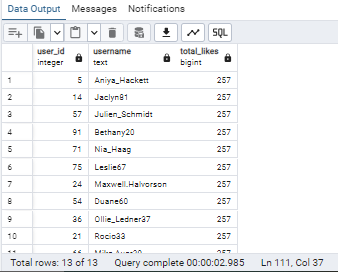

![alt text]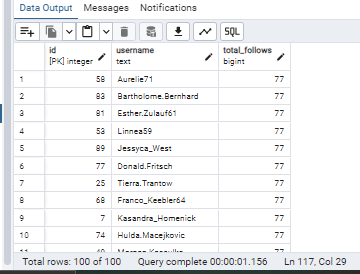

13 users with the highest number of likes which is 257 likes. A couple of users also have a large number of followers at 77 followers.